# Integration, Cointegration and Stationarity

**In time series analysis**, particularly in econometrics and finance, three closely related concepts—**stationarity**, **integration**, and **cointegration**—form the foundation for modeling persistent economic and financial data.

A time series is **stationary** if its statistical properties, such as mean and variance, remain constant over time, allowing standard statistical tools to be applied reliably. Many important series, like stock prices, GDP levels, or interest rates (in levels), are **non-stationary** and are said to be **integrated** of order 1 (denoted **I(1)**) when they contain a unit root and require first differencing to become stationary.

**Cointegration** describes a remarkable special case: even though individual series are non-stationary (typically **I(1)**), a particular linear combination of them can be stationary, revealing a stable long-run equilibrium relationship that prevents them from drifting apart indefinitely—such as between household consumption and disposable income, or between spot and futures prices.

These ideas, pioneered by Engle and Granger (whose work earned a Nobel Prize), help avoid misleading "spurious" regressions and enable powerful models like error-correction frameworks to capture both short-run dynamics and long-run relationships.

Import the necessary libraries

In [158]:
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
import yfinance as yf

from statsmodels.tsa.stattools import coint, adfuller
from matplotlib import pyplot as plt

#### Stationarity / Non-Stationarity

A commonly untested assumption in time series analysis is the **stationarity** of the data. Data are **stationary** when the parameters of the data generating process do not change over time.

As an example, let's consider two series, **A** and **B**.
- **Series A** is generated from a stationary process with fixed parameters.
- **Series B** is generated with parameters that change over time.

In [159]:
# Define a function that generates random data from a normal distribution
def generate_dataplot(params):
  mu = params[0]
  sigma = params[1]
  return np.random.normal(mu, sigma)

We will generate two different series: A and B
- Series A is stationary
- Series B is non-stationary

In [160]:
# set the parameters and the number of data points
params = [0, 1]
T = 200

A = pd.Series(index=range(T))
A.name = 'A'
for t in range(T):
  A[t] = generate_dataplot(params)
  
B = pd.Series(index=range(T))
B.name = 'B'
for t in range(T):
  params = (t * 0.1, 1)
  B[t] = generate_dataplot(params)

Plot the two different series in the same chart but different axes

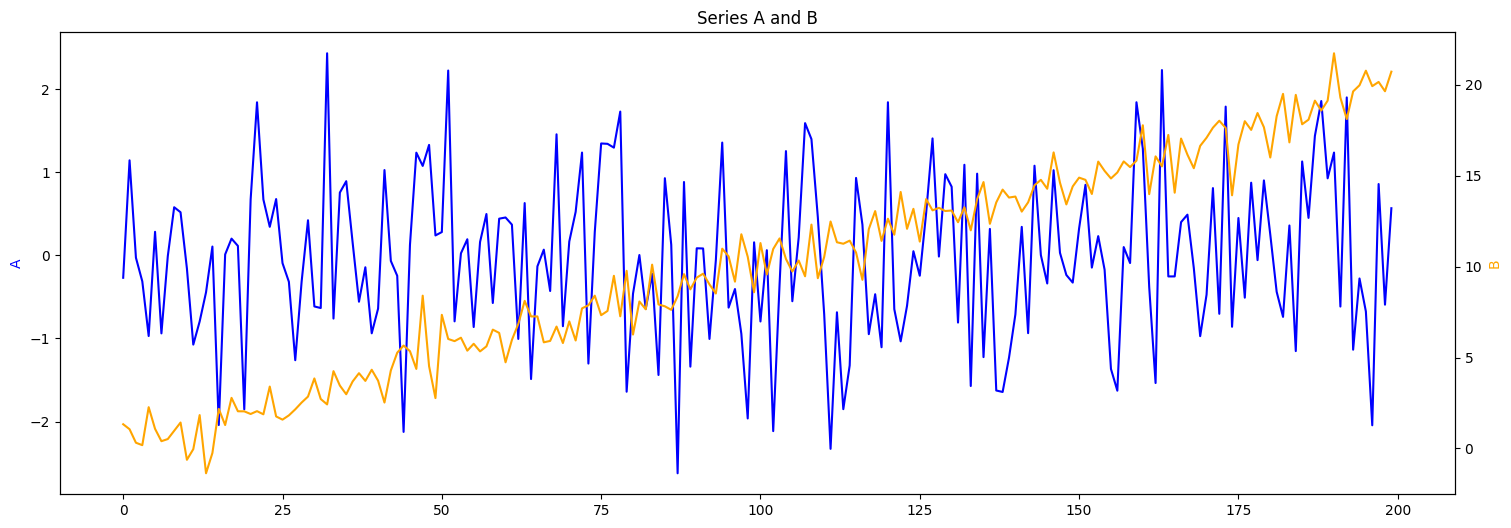

In [161]:
# Generate a plot of the two series in the same chart but different y axis
fig, ax1 = plt.subplots(figsize=(18, 6))
ax1.plot(A, color='blue')
ax1.set_ylabel('A', color='blue')
ax2 = ax1.twinx()
ax2.plot(B, color='orange')
ax2.set_ylabel('B', color='orange')
plt.title('Series A and B')
plt.show()

**Remarks: The Dangers of Non-Stationarity**

---

Many statistical tests have the underlying assumption that requires their datapoints to be stationary. Also, if you naively use certain statistics on a non-stationary data set, you will get garbage results.. Let us consider the mean of our Series B


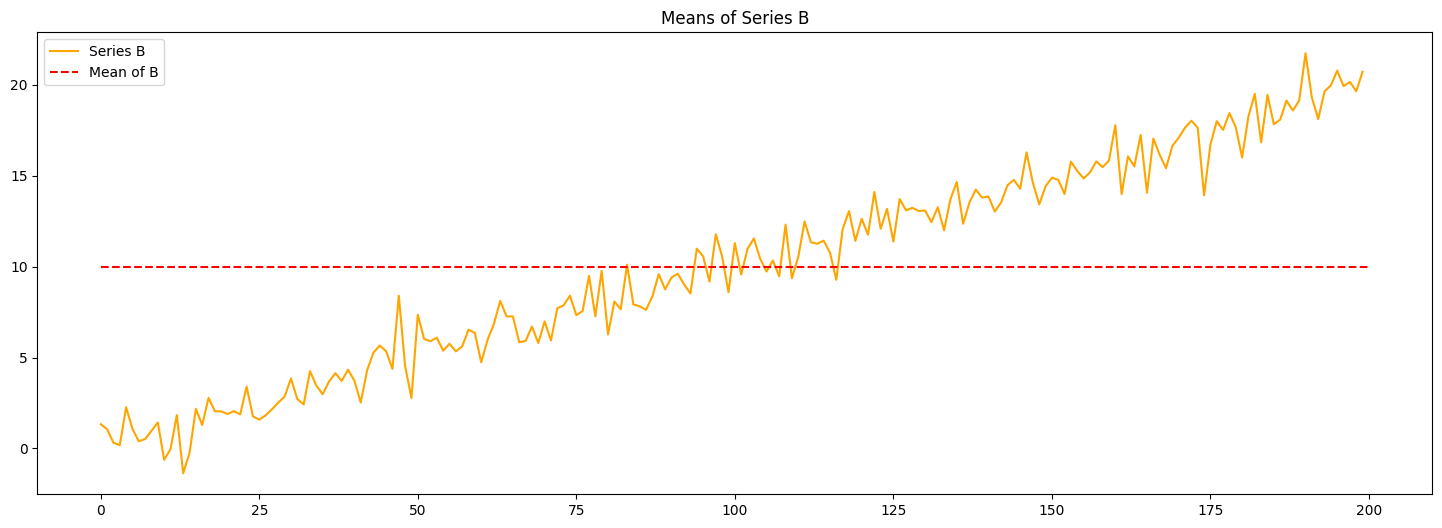

In [162]:
mean_b = B.mean()
plt.figure(figsize=(18, 6))
plt.plot(B, label='Series B', color='orange')
plt.hlines(mean_b, 0, len(B), label='Mean of B', color='red', linestyle='--')
plt.title('Means of Series B')
plt.legend()
plt.show()

**The Problem with Non-Stationarity: Meaningless Means & Forecasting Issues**

The computed mean will show the mean of all data points, but will not be useful for any forecasting of future states. It is meaningless when compared with any specific time point, especially when the series is a collection of data from different statistical regimes mashed together. **This is a simple and clear example of why non-stationarity can screw up analysis** — much more subtle problems arise in practice.

#### Testing for Stationarity (Augmented-Dickey-Fuller Test)

The Dickey-Fuller (simplified) tests whether a series follows a unit root process:

$$
\Delta y_t = \gamma y_{t-1} + \text{(optional lags \& trend)} + \epsilon_t
$$

- **Null hypothesis (H₀)**: γ = 0  → unit root → series is **non-stationary** (I(1) or worse)  
- **Alternative hypothesis (H₁)**: γ < 0  → series is **stationary** (mean-reverting)

As for our **Augmented Dickey-Fuller (ADF) test**, we are adding lagged differences to control for serial correlation in the errors:

$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^p \delta_i \Delta y_{t-i} + \epsilon_t
$$

Three common specifications (choose based on visual inspection / economic knowledge):
1. No constant, no trend  
2. Constant (intercept), no trend  
3. Constant + linear trend

**Interpretation of results**
- **p-value < 0.05** (or chosen significance level) → **reject H₀** → evidence for **stationarity**  
- **p-value > 0.05** → **fail to reject H₀** → series likely contains a **unit root** (non-stationary)

Critical values are **more negative** than standard t-tables (because of non-standard distribution under the null).

In [163]:
def check_for_stationarity(X, cutoff = 0.01):
  pvalue = adfuller(X)[1]
  if pvalue < cutoff:
    print(f'The series is stationary with p-value {pvalue}')
  else:
    print(f'The series is non-stationary with p-value {pvalue}')

In [164]:
# Testing for stationarity in Series A and B
check_for_stationarity(A)
check_for_stationarity(B)

The series is stationary with p-value 2.590330493442839e-26
The series is non-stationary with p-value 0.9571052947479725


#### Can we detect subtleties in time series?

We have seen from above that changing the mean makes the time series non-stationary. Here, we try to see if our stationarity test works on more subtle examples.

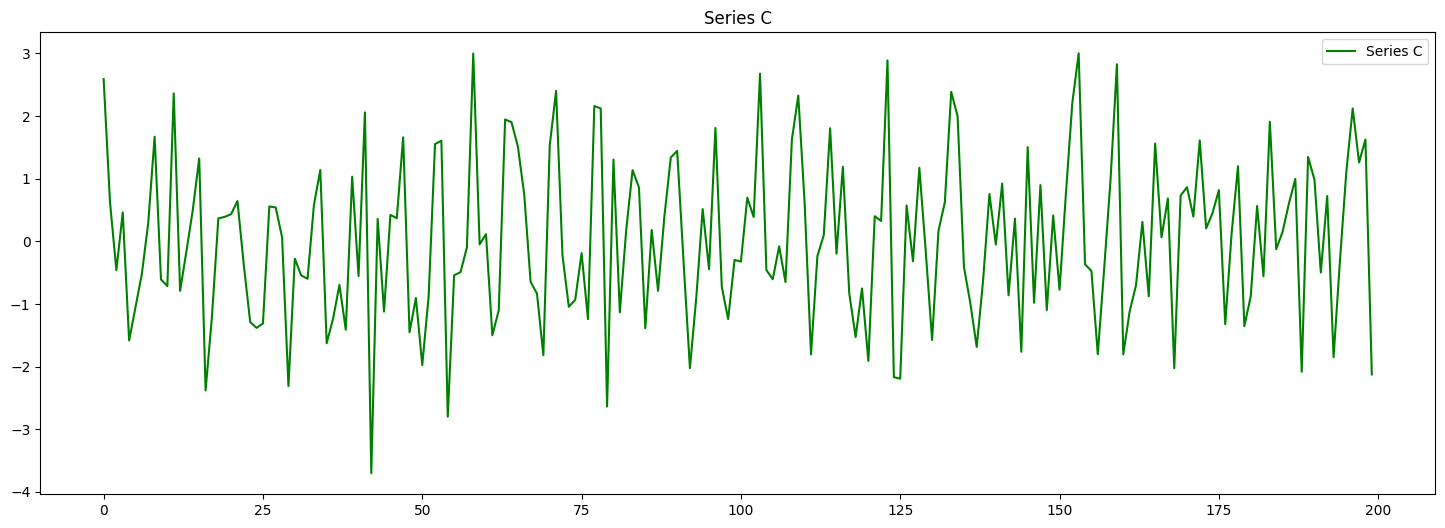

In [165]:
T = 200
C = pd.Series(index=range(T))
C.name = 'C'

for t in range(T):
  # Make the parameters dependent on time (speciically, the mean changes over time)
  params = (np.sin(t), 1)
  C[t] = generate_dataplot(params)
  
plt.figure(figsize=(18, 6))
plt.plot(C, label='Series C', color='green')
plt.title('Series C')
plt.legend()
plt.show()

In [166]:
# We can also test for stationarity in Series C, which shows that it is stationary even though its mean changes over time
check_for_stationarity(C)

The series is stationary with p-value 0.0003499622207372321


Remarks:

---

A **cyclic movement** of the mean will be **very difficult to tell apart from random noise**. In practice, with **noisy data** and **limited sample size**, it can be **hard to determine**:
- whether a series is truly **stationary**, or  
- whether any apparent drift is just **random noise** or part of a real **trend**.

In each individual case, the test **may or may not pick up** subtle effects like this.

#### Bottomline:

**The Augmented Dickey-Fuller (ADF) test is widely used** to test for stationarity — and in most practical applications, it is the go-to starting point. However, **in some cases** (such as the one illustrated above), it **fails to detect non-stationarity** even when the mean is clearly changing over time.

Despite this limitation, we can always turn to **other tests** to complement or cross-check the ADF result (e.g., KPSS, Phillips-Perron, variance ratio tests, etc.). **Most of the time, though, the ADF test will suffice** for standard time series work in economics, finance, and related fields.

**Key takeaway**

→ Use ADF as your primary / first test  
→ Be aware of its low power against certain alternatives (slow mean reversion, structural breaks, mild trends masked by noise)  
→ When in doubt → combine multiple tests and always **look at the plots**!

#### Order of Integration

**Moving Average Representation / Wold's Theorem**

An important concept in time series analysis is the **moving average representation** (Wold's decomposition). This representation expresses any (covariance-)stationary time series $Y_t$ as:

$$
Y_t = \sum_{j=0}^{\infty} b_j \epsilon_{t-j} + \eta_t
$$

where:
- $\epsilon_t$ is the 'innovation' series (white noise, unpredictable shocks)  
- $b_j$ are the moving average weights of the innovation series  
- $\eta_t$ is a deterministic series  

The key insight is as follows: $\epsilon_t = Y_t - \hat{Y}_t$ where $\hat{Y}_t$ is the optimal (minimum mean squared error) forecast of $Y_t$ using only information available before time $t$.  
In other words, the innovation is the part of $Y_t$ that cannot be predicted from the past — it represents pure randomness / new information. Each $b_j$ tells us how much past innovations influence the current value $Y_t$.

**Back to Order of Integration**

A time series is said to be **integrated of order $d$**, written **$I(d)$**, if the following condition holds in its moving average representation (after differencing $d$ times). We say a series is **$I(0)$** if:

$$
\sum_{k=0}^{\infty} |b_k|^2 < \infty
$$

In hand-wavy English: the autocorrelations of the series decay sufficiently quickly (square-summable MA coefficients).

**Important properties:**
- This condition is true for **all stationary series**  
- Stationarity $\implies I(0)$  
- But $I(0)$ **does not imply** stationarity (by itself — additional conditions are needed)

For higher orders of integration ($I(1)$, $I(2)$, etc.), please see:  
- [Wikipedia: Order of integration](https://en.wikipedia.org/wiki/Order_of_integration)  
- [Wikipedia: Wold's theorem](https://en.wikipedia.org/wiki/Wold%27s_theorem)

**Testing for $I(0)$**

In practice, directly checking whether $\sum |b_k|^2 < \infty$ is not possible. With finite data, we can only estimate a finite number of autocorrelations, so the sum is always finite in sample. Due to this difficulty, tests for $I(0)$ rely on **implying** the property rather than directly measuring it.

**Key practical rule:**
- If we find that a series is **stationary**, then it must also be **$I(0)$** (given the stationarity $\implies I(0)$ implication).  
- Conversely, if a series fails standard stationarity tests (e.g., ADF), it is typically **not $I(0)$**.

Let us take our original **stationary series A** from earlier. Since A is stationary, we know it is also **$I(0)$**.


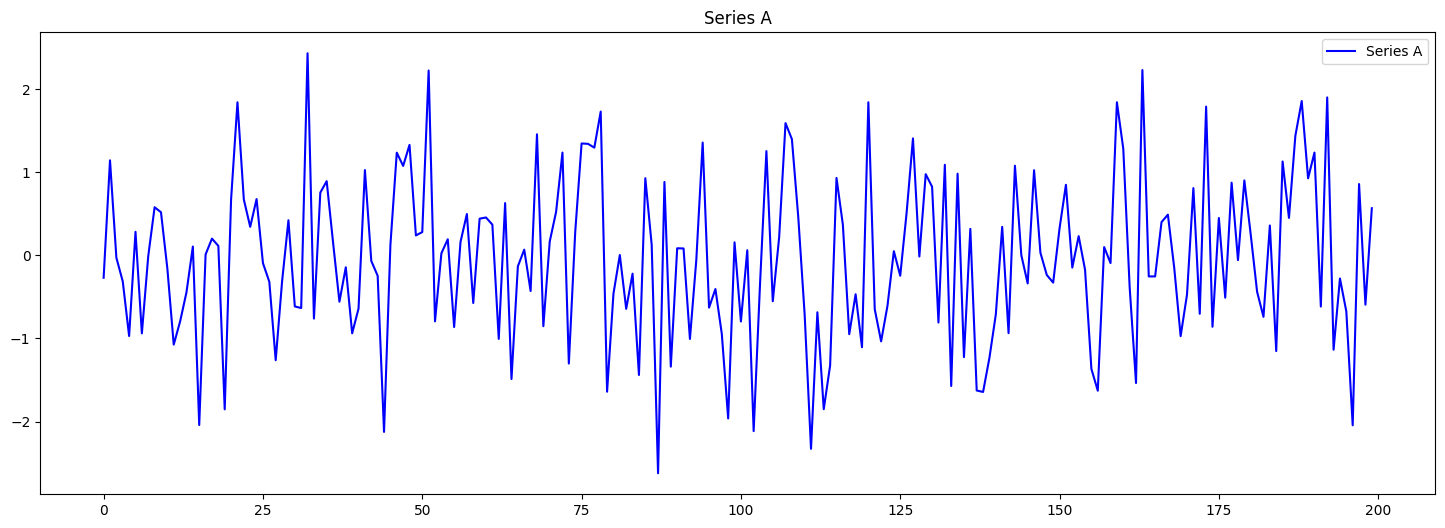

In [167]:
# Show the earlier plot of series A
plt.figure(figsize=(18, 6))
plt.plot(A, label='Series A', color='blue')
plt.title('Series A')
plt.legend()
plt.show()

If one takes an **I(0)** series and **cumulatively sums** it (discrete integration), the new series will be **I(1)**. Notice how this relates to the calculus concept of integration: integrating an I(0) process once gives an **I(1)** process.

The same relation applies in general: to get an **I(n)** series, start with an **I(0)** series and iteratively take the **cumulative sum** $n$ times.

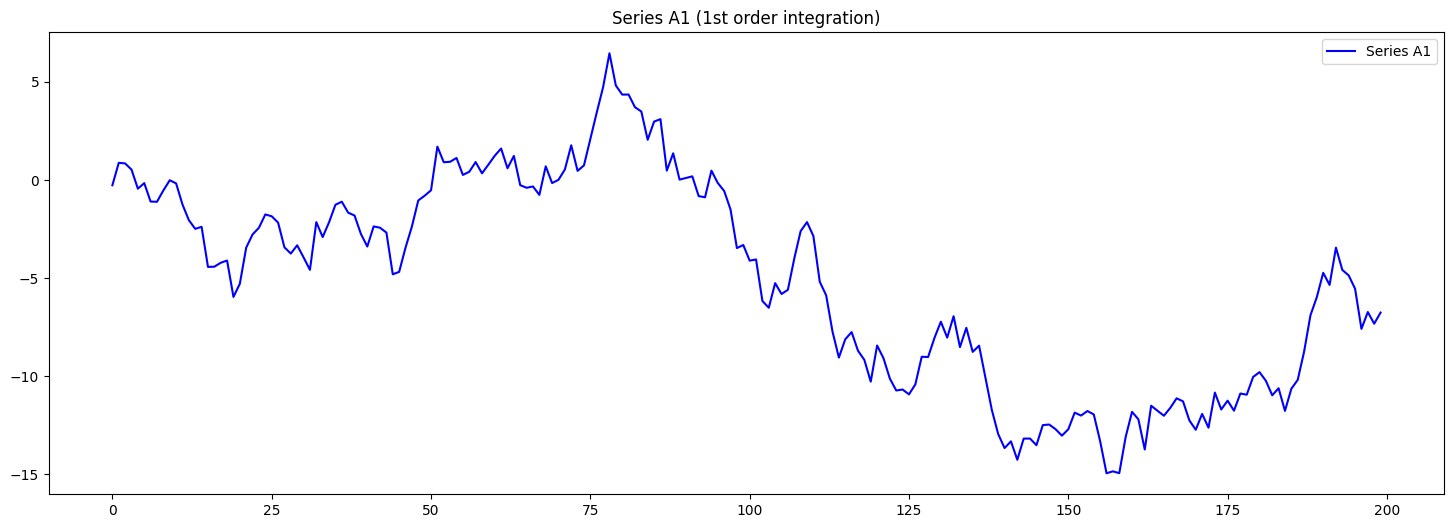

In [168]:
A1 = np.cumsum(A)

plt.figure(figsize=(18, 6))
plt.plot(A1, label='Series A1', color='blue')
plt.title('Series A1 (1st order integration)')
plt.legend()
plt.show()

If we want **I(2)**, we can take the **cumulative sum** again

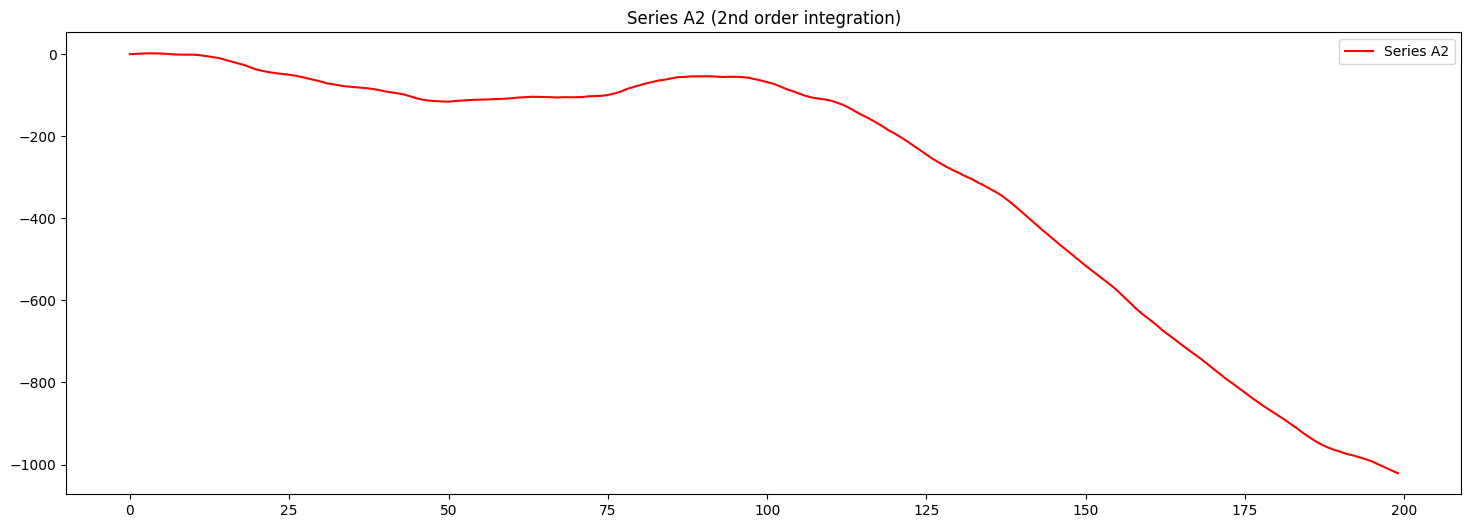

In [169]:
A2 = np.cumsum(A1)

plt.figure(figsize=(18, 6))
plt.plot(A2, label='Series A2', color='red')
plt.title('Series A2 (2nd order integration)')
plt.legend()
plt.show()

#### Breaking Down Orders of Integration

Conversely, to find the **order of integration** of a given series, we perform the **inverse** of a cumulative sum — which is the **Δ** (first difference) or more generally the **d-th difference** operator Specifically:

$$
(1 - L) X_t = X_t - X_{t-1} = \Delta X_t
$$

In general, for order $d$:

$$
(1 - L)^d X_t
$$

Here, $L$ is the **lag operator** (sometimes also written as $B$ for "backshift"):
- $L X_t = X_{t-1}$ (fetches the value from the previous period)  
- $L^k X_t = X_{t-k}$ (fetches the value from $k$ periods ago)

So explicitly:

$$
(1 - L) X_t = X_t - L X_t = X_t - X_{t-1}
$$

A series $Y_t$ is **integrated of order 1**, written **$Y_t \sim I(1)$**, if the **first difference** is stationary:

$$
Y_t \sim I(1) \quad \Longleftrightarrow \quad (1 - L) Y_t = Y_t - Y_{t-1} \sim I(0)
$$

In other words: if you take an **$I(0)$** (stationary) series and **cumulatively sum** it, you obtain an **$I(1)$** series. Conversely, if you take an **$I(1)$** series and **difference** it once,   you recover an **$I(0)$** series.

**Important Take-Away**

Once all the math has settled, remember the core practical rule:

**Any stationary series is $I(0)$**
This is the most useful implication for applied work:  
→ Test for stationarity → if stationary → the series is $I(0)$  
→ If non-stationary → difference once → re-test → repeat until you reach $I(0)$

Let us show an example with real world data

In [170]:
symbol = 'MSFT'
start_date = '2014-01-01'
end_date = '2015-01-01'
price = yf.download(symbol, start=start_date, end=end_date)['Close']

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_14418/3726948633.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(symbol, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


Check for stationarity of price data

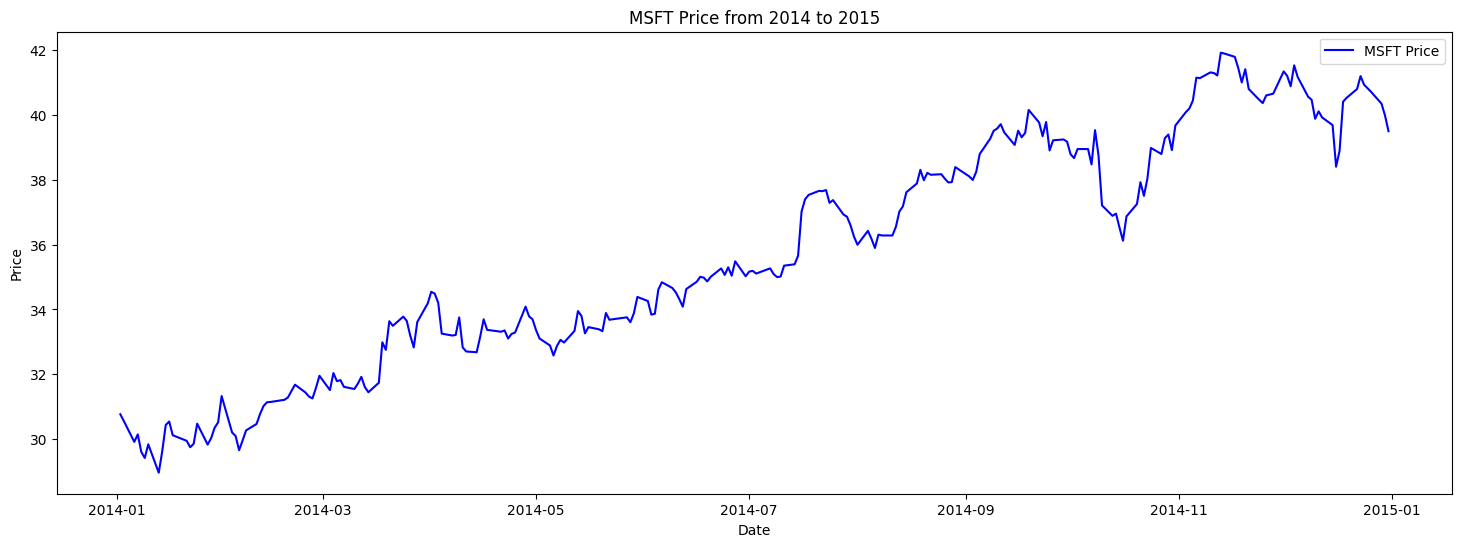

The series is non-stationary with p-value 0.6966864451132186


In [171]:
# Plot the price series
plt.figure(figsize=(18, 6))
plt.plot(price, label='MSFT Price', color='blue')
plt.title('MSFT Price from 2014 to 2015')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Check for stationarity in the price series
check_for_stationarity(price)

Let us now take the first-order difference (i.e the delta of the series), giving us the additive returns, and then we will check for stationarity

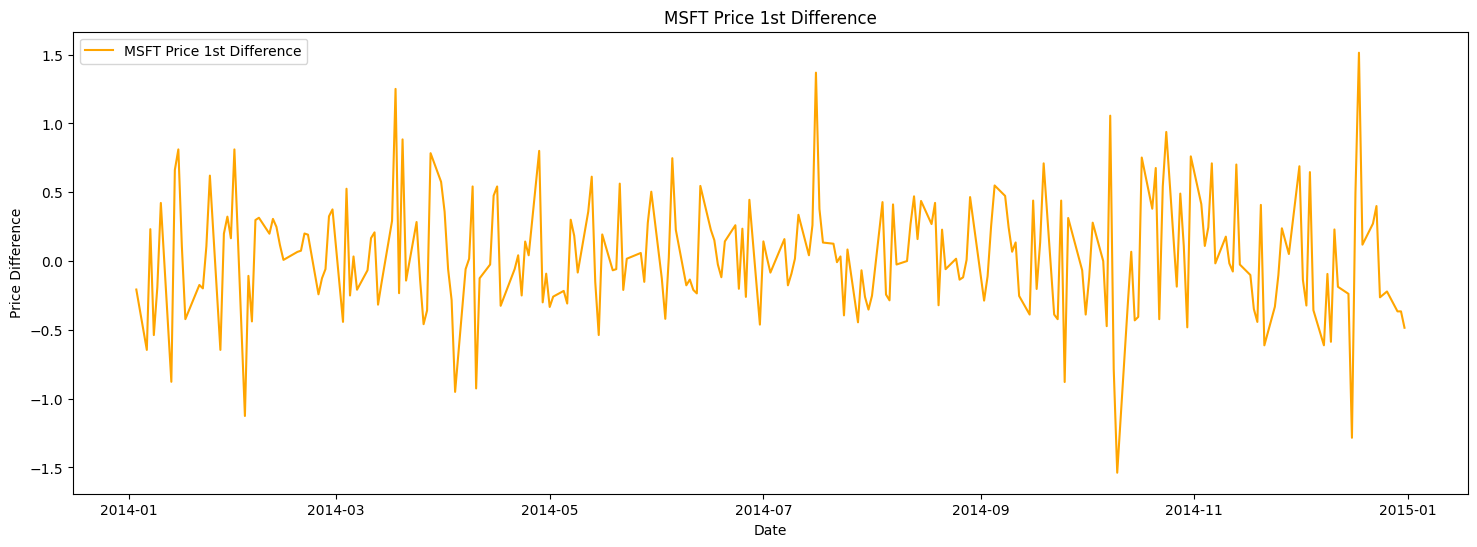

The series is stationary with p-value 1.3001149498543582e-28


In [172]:
price1 = price.diff().dropna()
price1.name = 'MSFT Price 1st Difference'

# Plot the first difference of the price series
plt.figure(figsize=(18, 6))
plt.plot(price1, label='MSFT Price 1st Difference', color='orange')
plt.title('MSFT Price 1st Difference')
plt.xlabel('Date')
plt.ylabel('Price Difference')
plt.legend()
plt.show()

# Check for stationarity in the first difference of the price series
check_for_stationarity(price1)

We can also check for stationarity in multiplicative returns, where we derive it from the price data using pandas ```pct_change()```

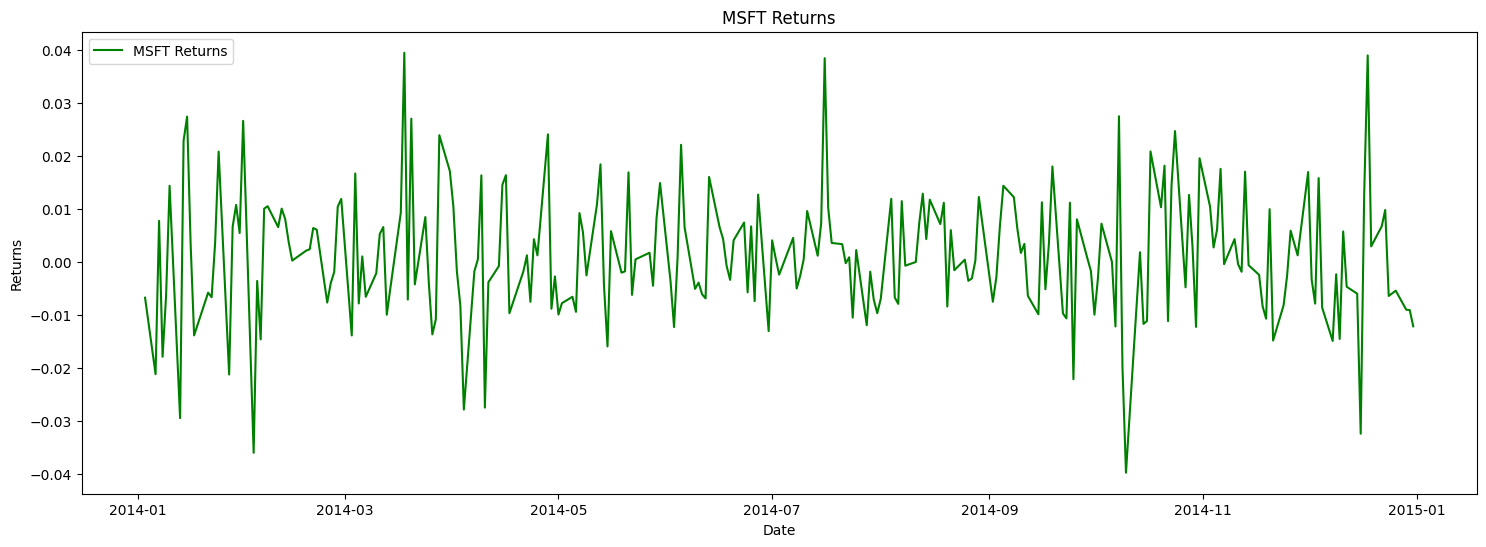

The series is stationary with p-value 6.938902052014399e-29


In [173]:
returns_1 = price.pct_change().dropna()
returns_1.name = 'MSFT Returns'

# Plot the returns of the price series
plt.figure(figsize=(18, 6))
plt.plot(returns_1, label='MSFT Returns', color='green')
plt.title('MSFT Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

# Check for stationarity in the returns of the price series
check_for_stationarity(returns_1)

Remarks:

---

It seems that **multiplicative returns** are also **stationary**. Both **multiplicative** and **additive deltas** (returns) on a series tend to capture similar pieces of stationary information,  
so it is not surprising that both are typically stationary. In practice, this might **not always** be the case — depending on the asset, market regime, volatility clustering, or other features.

**IMPORTANT NOTE**

You should **not** naively assume that because a time series was stationary in the past, it will **continue to be stationary** in the future. Tests for **consistency of stationarity** — such as cross-validation, out-of-sample testing, rolling window checks, or regime-detection methods — are **necessary**. This is true for **any statistical property**, not just stationarity.

We reiterate here: **Returns** may go in and out of stationarity, and may be **stationary or non-stationary** depending on the **timeframe**, **sampling frequency**, market conditions, or lookback period.

#### Cointegration

Finally, now that we have discussed **stationarity** and **order of integration**, we can move on to the powerful concept of **cointegration**.

**Definition: Linear Combination**

A **linear combination** of time series $(X_1, X_2, \dots, X_k)$ is a new time series $Y$ constructed as follows for some set of real numbers $b_1, \dots, b_k$:

$$
Y = b_1 X_1 + b_2 X_2 + \dots + b_k X_k
$$

**Formal Definition of Cointegration**

The formal definition of cointegration is as follows:
> For a set of time series $(X_1, X_2, \dots, X_k)$, if **all** the series are **I(1)**, and there exists **some linear combination** of them that is **I(0)** (stationary) then we say the set of time series is **cointegrated**.

In other words: the individual series are **non-stationary** (integrated of order 1), but a particular linear combination is **stationary**.

**Example**

Suppose we have three time series $X_1$, $X_2$, and $X_3$, all of which are **I(1)**. Consider the linear combination:

$$
2X_1 + X_2 + 0 \cdot X_3 = 2X_1 + X_2
$$

If this combination $2X_1 + X_2$ is **I(0)** (stationary), then the set $\{X_1, X_2, X_3\}$ is **cointegrated**  (even though $X_3$ has a coefficient of zero in this particular combination).

**Intuition**

The intuition here is that for some linear combination of the series, the result **lacks autocovariance structure** and is **mostly noise** (i.e., stationary white-noise-like behavior). This is extremely useful in practice — especially in **pairs trading** and **statistical arbitrage**. We can find assets whose **prices** are cointegrated: the linear combination $b_1 A_t + b_2 B_t$ (or more generally $\beta_1 \log A_t + \beta_2 \log B_t$ in log-prices) is mean-reverting. When the spread deviates significantly from its long-run equilibrium, we can bet on convergence (place trades accordingly).

Simulated Data Example

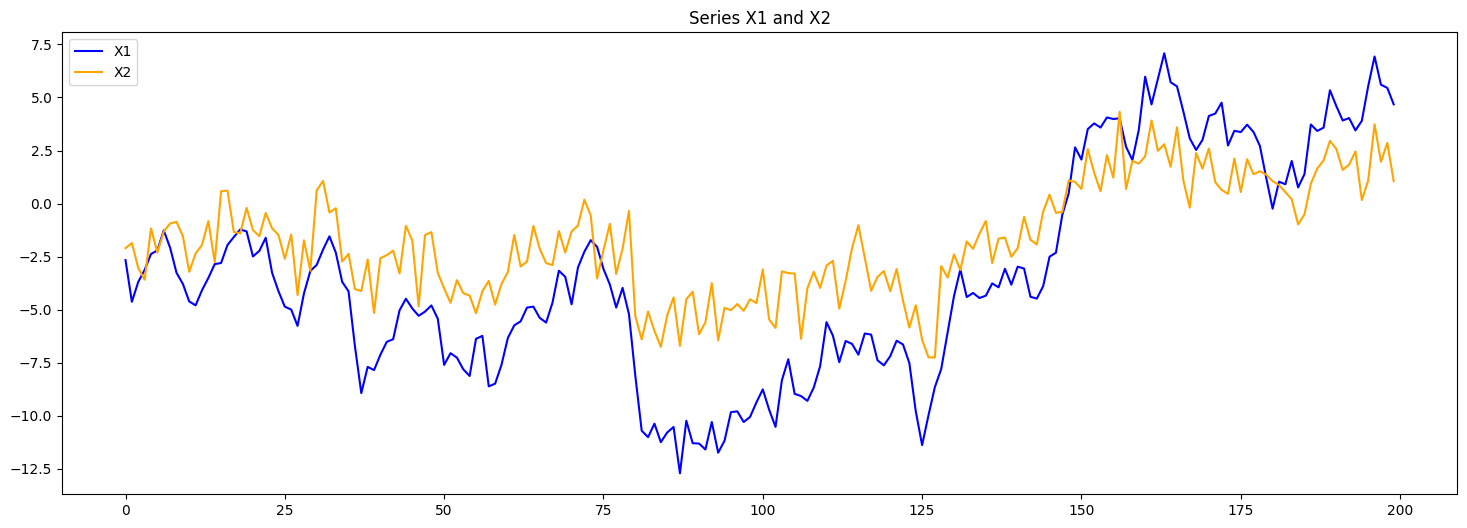

In [174]:
n = 200

X1 = np.random.normal(0, 1, n)
X1 = np.cumsum(X1)
X1 = pd.Series(X1)
X1.name = 'X1'

# Make X2 a linear combination of X1 plus some noise
X2 = 0.5 * X1 + np.random.normal(0, 1, n)
X2 = pd.Series(X2)
X2.name = 'X2'

# Plot the two series
plt.figure(figsize=(18, 6))
plt.plot(X1, label='X1', color='blue')
plt.plot(X2, label='X2', color='orange')
plt.title('Series X1 and X2')
plt.legend()
plt.show()

Since $X_{2}$ is just and $I(1)$ series plus some noise, it should still be $I(1)$. Let us verify it now.

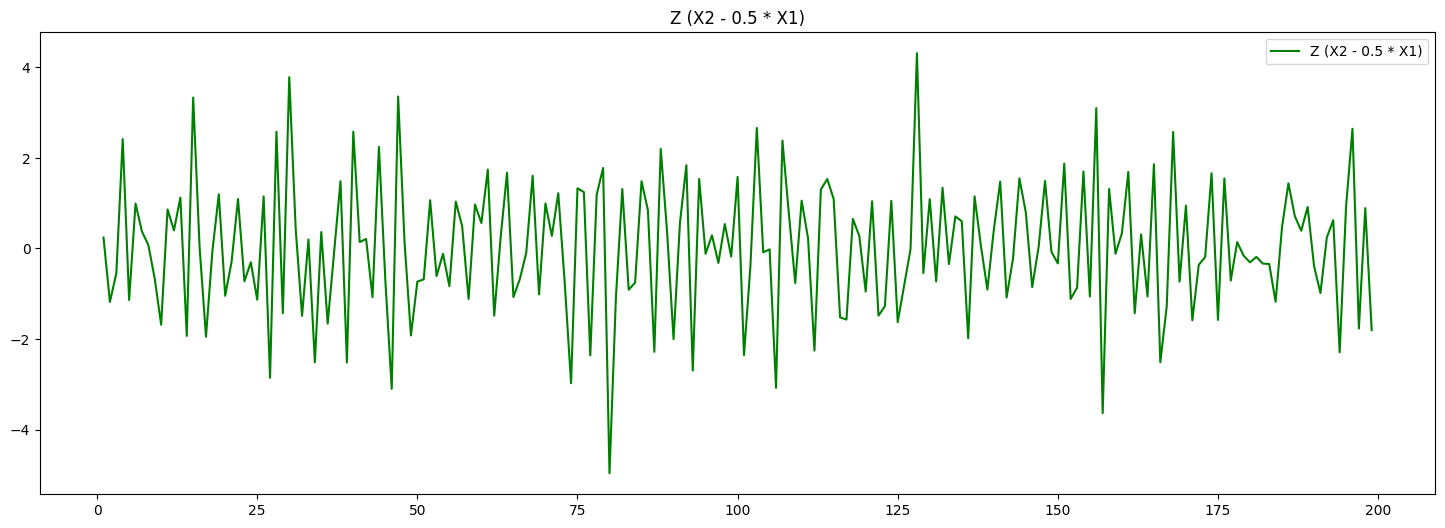

The series is stationary with p-value 1.6940001442195365e-08


In [175]:
Z = X2.diff().dropna()
Z.name = 'Z (X2 - 0.5 * X1)'

# Plot the Z series
plt.figure(figsize=(18, 6))
plt.plot(Z, label='Z (X2 - 0.5 * X1)', color='green')
plt.title('Z (X2 - 0.5 * X1)')
plt.legend()
plt.show()

# Check for stationarity in the Z series
check_for_stationarity(Z)

Now, to show that there is cointegration, we will need to find some linear combination of $X_{1}$ and $X_{2}$ that is stationary. We can take $X_{1} - X_{2}$. By our definition, all that remains should just be the stationary noise.

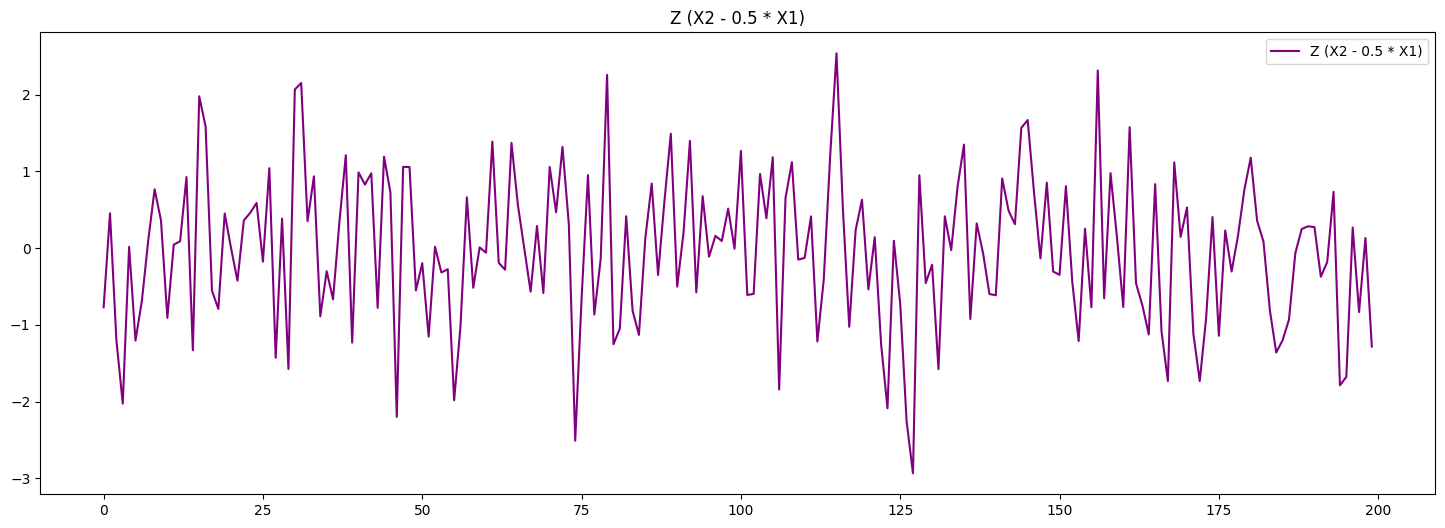

The series is stationary with p-value 1.7783896636230512e-25


In [176]:
Z = X2 - 0.5 * X1
Z.name = 'Z'

# Plot the Z series
plt.figure(figsize=(18, 6))
plt.plot(Z, label='Z (X2 - 0.5 * X1)', color='Purple')
plt.title('Z (X2 - 0.5 * X1)')
plt.legend()
plt.show()

# Check for stationarity in the Z series
check_for_stationarity(Z)

#### Testing for Cointegration

There are a bunch of ways to test for cointegration. This [Wikipedia article](https://en.wikipedia.org/wiki/Cointegration) describes several approaches. In general, we are just trying to solve for the coefficients $b_1, \dots, b_k$ that produce an $I(0)$ (stationary) linear combination. If we **reject** the null hypothesis that the set is **not** cointegrated, then we conclude the series are cointegrated.

However:
- This approach can lead to **Type I errors** (false positives) if our estimated coefficients do not pass a stationarity check on the residual.  
- **Type II errors** (false negatives) are generally okay here, as they are conservative — we avoid making wrong forecasts or spurious claims of cointegration.

**In Practice: Common Method for Two Series (Engle-Granger Style)**

A very common way to test for cointegration between **two time series** is to use **ordinary least squares (OLS) regression** to estimate $\beta$ in the model:

$$
X_{2,t} = \alpha + \beta X_{1,t} + \epsilon_t
$$

The idea is:
- If the two series are **cointegrated**, we can "remove" $X_2$'s dependency on $X_1$ by forming the linear combination $X_{2,t} - \beta X_{1,t} - \alpha$, leaving behind only **stationary noise** $\epsilon_t$.

In other words, the **residual**:
$$
\hat{\epsilon}_t = X_{2,t} - \hat{\alpha} - \hat{\beta} X_{1,t}
$$

should be **stationary** (i.e., $I(0)$) if cointegration holds.

Illustrating **Cointegration** with real data

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_14418/609060758.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed


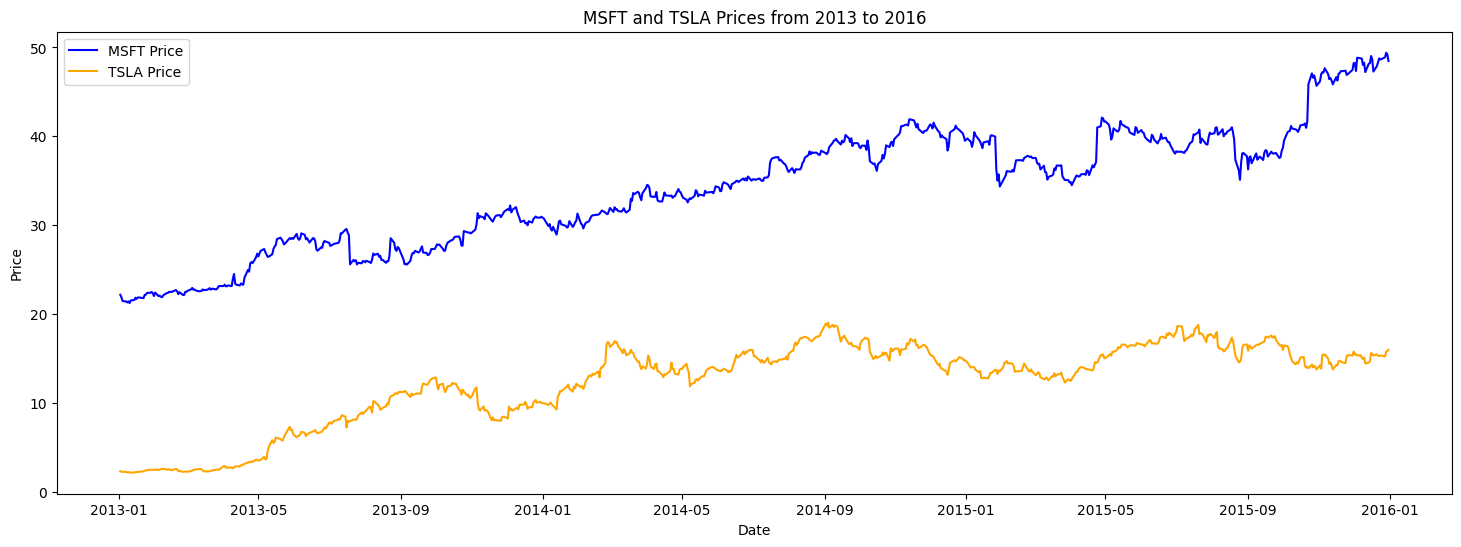

In [177]:
tickers = ['MSFT', 'TSLA']
start_date = '2013-01-01'
end_date = '2016-01-01'
prices = yf.download(tickers, start=start_date, end=end_date)['Close']

x1 = prices['MSFT']
x2 = prices['TSLA']

# Plot the two price series
plt.figure(figsize=(18, 6))
plt.plot(x1, label='MSFT Price', color='blue')
plt.plot(x2, label='TSLA Price', color='orange')
plt.title('MSFT and TSLA Prices from 2013 to 2016')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Well, at first glance it seems like both stocks are moving in tandem with one another. Let us construct a linear regression of the two stocks.

In [178]:
x1 = sm.add_constant(x1)
model = sm.OLS(x2, x1).fit()
print(model.summary())
print(model.params)

                            OLS Regression Results                            
Dep. Variable:                   TSLA   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     1645.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.07e-191
Time:                        00:44:43   Log-Likelihood:                -1786.9
No. Observations:                 756   AIC:                             3578.
Df Residuals:                     754   BIC:                             3587.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.9306      0.486    -14.273      0.0

Given our beta and constant, let us now construct our linear regression model

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_14418/4066001297.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = model.params[1]


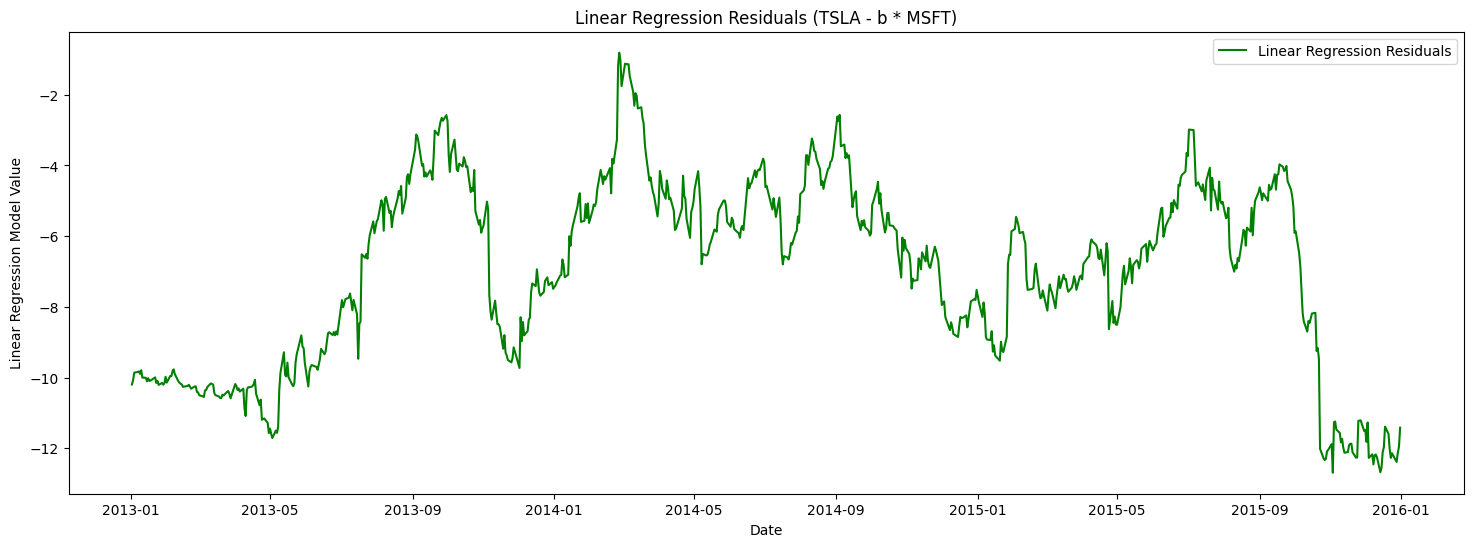

The series is non-stationary with p-value 0.23422409350122336


In [179]:
b = model.params[1]
Z = x2 - b * x1['MSFT']
Z.name = 'Linear Regression Residuals'

# Plot the linear regression model
plt.figure(figsize=(18, 6))
plt.plot(Z, label='Linear Regression Residuals', color='green')
plt.title('Linear Regression Residuals (TSLA - b * MSFT)')
plt.xlabel('Date')
plt.ylabel('Linear Regression Model Value')
plt.legend()
plt.show()

# Check for stationarity in the linear regression residuals
check_for_stationarity(Z)

From our test above, we can see that the two stocks are not **cointegrated** during the specified time period. Feel free to vary the stocks and time periods to check for cases where the pairs are cointegrated.

#### Consider another example: XOM and EWC (but set the p-value of our test to be 5%)

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_14418/3215944086.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed


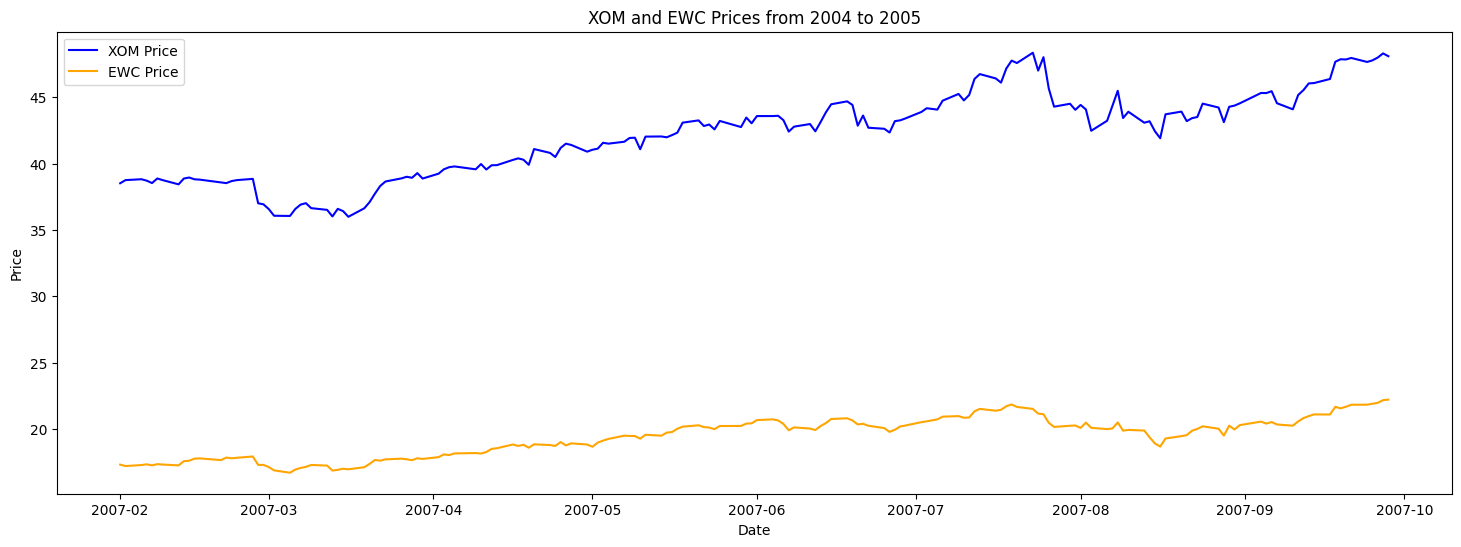

                            OLS Regression Results                            
Dep. Variable:                    EWC   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     3064.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.78e-108
Time:                        00:44:43   Log-Likelihood:                -51.568
No. Observations:                 167   AIC:                             107.1
Df Residuals:                     165   BIC:                             113.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7995      0.338      2.367      0.0

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_14418/3215944086.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = model.params[1]


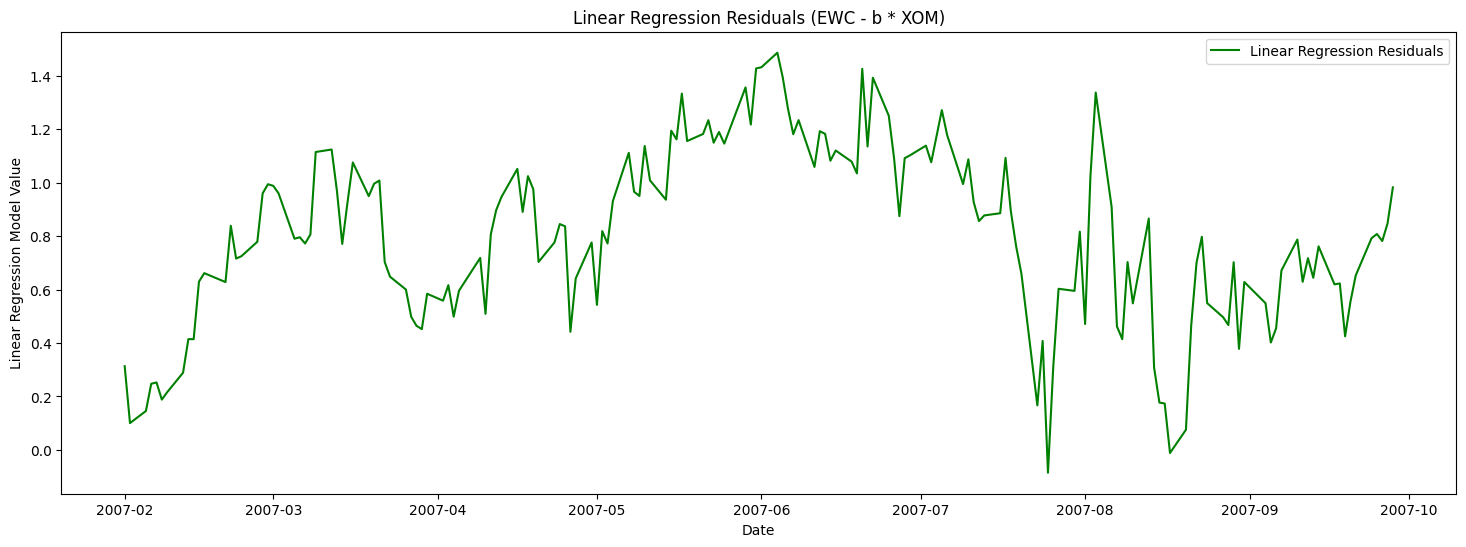

The series is stationary with p-value 0.01231750112792733


In [180]:
# Ticker symboles for PepsiCo and Coca-Cola
tickers = ['XOM', 'EWC']
start_date = '2007-02-01'
end_date = '2007-10-01'
prices = yf.download(tickers, start=start_date, end=end_date)['Close']

x1 = prices['XOM']
x2 = prices['EWC']

# Plot the two price series
plt.figure(figsize=(18, 6))
plt.plot(x1, label='XOM Price', color='blue')
plt.plot(x2, label='EWC Price', color='orange')
plt.title('XOM and EWC Prices from 2004 to 2005')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Perform linear regression of EWC on XOM
x1_const = sm.add_constant(x1)
model = sm.OLS(x2, x1_const).fit()
print(model.summary())
print(model.params)

# Plot the linear regression model
b = model.params[1]
Z = x2 - b * x1
Z.name = 'Linear Regression Residuals'
plt.figure(figsize=(18, 6))
plt.plot(Z, label='Linear Regression Residuals', color='green')
plt.title('Linear Regression Residuals (EWC - b * XOM)')
plt.xlabel('Date')
plt.ylabel('Linear Regression Model Value')
plt.legend()
plt.show()

# Check for stationarity in the linear regression residuals
check_for_stationarity(Z, cutoff=0.05)

Using the in-built cointegration test package

In [181]:
coint(x1, x2)
print(f'Cointegration test p-value: {coint(x1, x2)[1]}')

Cointegration test p-value: 0.05087081035815589


**Note**

There will be some discrepancies between the p-value derived from the ```coint()``` package and our derived value, since we are using ADF in our function to test for stationarity, but a different test may be used in ```coint()```